# 02 · From pixels to a sequence: backbone, projection, masks, positions

> **Paper:** §3.2 "Backbone" and "Transformer encoder" · **Code:** [`models/backbone.py`](../models/backbone.py), [`models/position_encoding.py`](../models/position_encoding.py)

A transformer eats a **sequence** of vectors. A photo is a **2-D grid** of pixels. This notebook is the bridge, and it is almost entirely about **tensor shapes**.

We'll follow one image through four transformations:

```
(3, 800, 1066)   PIL image -> tensor                    3 channels, H, W
(2048, 25, 34)   ResNet-50                              lots of channels, tiny grid
( 256, 25, 34)   1x1 conv "input_proj"                  squeeze channels to d=256
( 850, 256)      flatten H,W into one sequence axis     850 = 25*34 "pixels" as tokens
```

Plus two things that trip everyone up: the **padding mask** and the **positional encoding**.

In [1]:
%matplotlib inline
import torch, matplotlib.pyplot as plt
from detr_utils import *   # noqa: F403

device = get_device()
model = load_pretrained_detr(device=device)
im = load_image("cats")
print("device:", device, "| image (W,H):", im.size)

/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


device: mps | image (W,H): (640, 480)


## 1. Preprocessing: why there is no fixed input size

Recall the cats-and-dogs classifier, where every image was forced to 150×150. Detection can't do that — squashing an image distorts the boxes you're trying to predict.

DETR instead resizes the **shortest side to 800px** and lets the other side land wherever it lands.

In [2]:
x = default_transform(im)               # shape: (3, H, W)   -- Resize(800) + ToTensor + Normalize
print("PIL  (W, H)      :", im.size)
print("tensor (C, H, W) :", tuple(x.shape))
print("  -> shortest side is exactly 800:", min(x.shape[1:]) == 800)
print("  -> aspect ratio preserved      :",
      round(im.size[0]/im.size[1], 3), "vs", round(x.shape[2]/x.shape[1], 3))

# Different image -> different tensor shape. That is allowed here.
im2 = load_image("street")
print("\nanother image:", im2.size, "->", tuple(default_transform(im2).shape))

PIL  (W, H)      : (640, 480)
tensor (C, H, W) : (3, 800, 1066)
  -> shortest side is exactly 800: True
  -> aspect ratio preserved      : 1.333 vs 1.333

another image: (640, 426) -> (3, 800, 1201)


### The batch problem, and `NestedTensor`

Two images of different shapes cannot be `torch.stack`ed. DETR's fix is to pad every image in a batch up to the largest H and W, and carry a **boolean mask** marking which pixels are real padding.

That pair — `(padded_tensor, mask)` — is what the repo calls a `NestedTensor` ([`util/misc.py`](../util/misc.py)).

In [3]:
from util.misc import nested_tensor_from_tensor_list

batch = nested_tensor_from_tensor_list([default_transform(im), default_transform(im2)])
print("tensors shape:", tuple(batch.tensors.shape), "  <- (B, 3, maxH, maxW), both padded")
print("mask    shape:", tuple(batch.mask.shape),    "  <- (B, maxH, maxW), True = padding")
print()
for i in range(2):
    real = (~batch.mask[i]).sum().item()
    total = batch.mask[i].numel()
    print(f"  image {i}: {real:,} real pixels / {total:,} slots  ({100*real/total:.1f}% real)")

tensors shape: (2, 3, 800, 1201)   <- (B, 3, maxH, maxW), both padded
mask    shape: (2, 800, 1201)   <- (B, maxH, maxW), True = padding

  image 0: 852,800 real pixels / 960,800 slots  (88.8% real)
  image 1: 960,800 real pixels / 960,800 slots  (100.0% real)


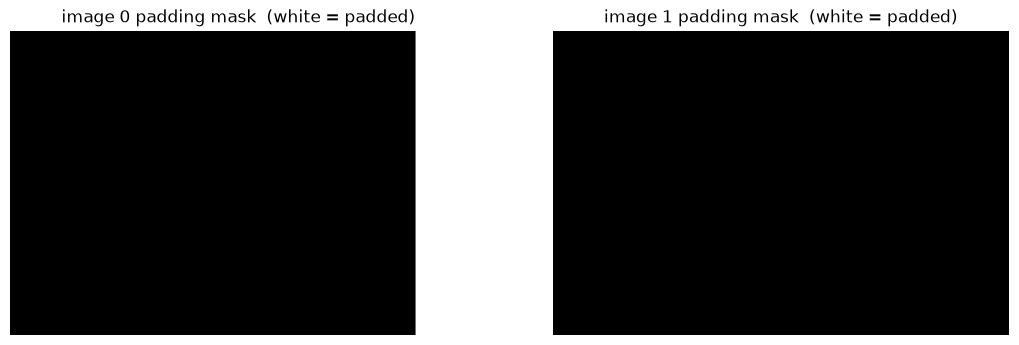

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for i, ax in enumerate(axes):
    ax.imshow(batch.mask[i].cpu(), cmap="gray")
    ax.set_title(f"image {i} padding mask  (white = padded)")
    ax.axis("off")
plt.tight_layout(); plt.show()

**Why the mask matters.** Self-attention is global: without a mask, every real pixel would attend to the grey padding as if it were image content. The mask is threaded all the way through to `nn.MultiheadAttention(key_padding_mask=...)` in [`models/transformer.py:56`](../models/transformer.py#L56).

From here on we use a **single image**, so `B=1` and the mask is all-`False` (nothing padded).

## 2. The backbone: trading resolution for semantics

ResNet-50, with its final classification head removed. It is extracted with `IntermediateLayerGetter(backbone, return_layers={'layer4': '0'})` — i.e. stop at `layer4` and hand back that feature map.

In [5]:
single = nested_tensor_from_tensor_list([default_transform(im)]).to(device)
print("input :", tuple(single.tensors.shape))

with torch.no_grad():
    features, pos = model.backbone(single)     # Joiner: returns features AND position encodings

src, mask = features[-1].decompose()           # unpack the NestedTensor
print("output:", tuple(src.shape), "  <- (B, C, H/32, W/32)")
print()
H0, W0 = single.tensors.shape[-2:]
C, H, W = src.shape[1:]
print(f"  spatial : {H0}x{W0}  ->  {H}x{W}      (divided by {H0//H}, the ResNet stride)")
print(f"  channels: 3          ->  {C}")
print(f"  so one 'pixel' of the feature map summarizes a {H0//H}x{W0//W} patch of the photo")

input : (1, 3, 800, 1066)


output: (1, 2048, 25, 34)   <- (B, C, H/32, W/32)

  spatial : 800x1066  ->  25x34      (divided by 32, the ResNet stride)
  channels: 3          ->  2048
  so one 'pixel' of the feature map summarizes a 32x31 patch of the photo


This is the classic CNN trade: **spatial resolution down 32×, channel depth up 683×**. Each of the 2048 channels is a learned feature detector; each grid cell now describes a 32×32 patch of the original photo.

Matching the paper (§3.2): *"a conventional CNN backbone generates a lower-resolution activation map f ∈ ℝ^(C×H×W). Typical values we use are C = 2048 and H, W = H₀/32, W₀/32."*

### Frozen BatchNorm — a detail worth knowing

Detection trains with tiny batches (2 images per GPU). BatchNorm statistics computed over 2 images are garbage, so DETR replaces every `BatchNorm2d` with `FrozenBatchNorm2d`: the running mean/var from ImageNet pretraining are baked in as constants.

In [6]:
from models.backbone import FrozenBatchNorm2d
bn = [m for m in model.backbone.modules() if isinstance(m, FrozenBatchNorm2d)]
print(f"FrozenBatchNorm2d layers : {len(bn)}")
print(f"trainable BatchNorm2d    : {sum(1 for m in model.backbone.modules() if isinstance(m, torch.nn.BatchNorm2d))}")
print()
p = list(bn[0].buffers())
print("FrozenBatchNorm2d stores weight/bias/mean/var as *buffers*, not parameters:")
print("   buffers   :", len(p), "  parameters:", len(list(bn[0].parameters())))
print("   -> nothing to learn, nothing to update")

FrozenBatchNorm2d layers : 53
trainable BatchNorm2d    : 0

FrozenBatchNorm2d stores weight/bias/mean/var as *buffers*, not parameters:
   buffers   : 4   parameters: 0
   -> nothing to learn, nothing to update


## 3. `input_proj`: 2048 → 256 with a 1×1 convolution

A transformer with `d_model=2048` would be enormous. DETR shrinks the channel dimension to **d = 256** first, with a 1×1 convolution.

A 1×1 conv is worth pausing on if you're new to CNNs: it touches **one pixel at a time** and only mixes *channels*. It is exactly an `nn.Linear(2048, 256)` applied independently at every grid location — the same "one weight matrix, applied per position" idea as `nn.Linear` over a batch.

In [7]:
print("input_proj:", model.input_proj)

with torch.no_grad():
    proj = model.input_proj(src)      # shape: (B, 256, H, W)

print("\nbefore:", tuple(src.shape))
print("after :", tuple(proj.shape), "  <- H and W untouched, only C changed")
print()
w = model.input_proj.weight
print("weight shape:", tuple(w.shape), " = (out_ch, in_ch, 1, 1)")
print("params      :", w.numel() + model.input_proj.bias.numel(),
      "= 2048*256 + 256, identical to nn.Linear(2048, 256)")

input_proj: Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))

before: (1, 2048, 25, 34)
after : (1, 256, 25, 34)   <- H and W untouched, only C changed

weight shape: (256, 2048, 1, 1)  = (out_ch, in_ch, 1, 1)
params      : 524544 = 2048*256 + 256, identical to nn.Linear(2048, 256)


## 4. Flatten the grid into a sequence

Now the actual pixels→tokens step. It is one line in [`models/transformer.py:50`](../models/transformer.py#L50):

```python
src = src.flatten(2).permute(2, 0, 1)   # (B, C, H, W) -> (HW, B, C)
```

Read it in two moves:
- `.flatten(2)` collapses dims 2 onward: `(B, 256, 25, 34)` → `(B, 256, 850)`
- `.permute(2, 0, 1)` reorders to `(850, B, 256)`

**850 = 25 × 34.** Each grid cell becomes one token in a sequence of 850. This DETR predates `batch_first=True`, so it uses the older `(sequence, batch, channels)` convention.

In [8]:
B, C, H, W = proj.shape
seq = proj.flatten(2).permute(2, 0, 1)      # shape: (H*W, B, C)

print(f"(B, C, H, W)  = {tuple(proj.shape)}")
print(f"(H*W, B, C)   = {tuple(seq.shape)}     <- {H} * {W} = {H*W} tokens")
print()
print("sequence length is NOT fixed -- it depends on the image:")
import math
for name in ["cats", "street", "horses"]:
    t = default_transform(load_image(name))
    # CAREFUL: ResNet rounds UP, not down. 1066/32 = 33.3 -> 34, not 33.
    # Use ceil, or you will be off by a whole row/column of tokens.
    h, w = math.ceil(t.shape[1] / 32), math.ceil(t.shape[2] / 32)
    with torch.no_grad():                      # verify against the real backbone
        nt = nested_tensor_from_tensor_list([t]).to(device)
        real = model.backbone(nt)[0][-1].tensors.shape[-2:]
    ok = "OK" if (h, w) == tuple(real) else f"MISMATCH (real {tuple(real)})"
    print(f"   {name:<8} {tuple(t.shape)} -> grid {h}x{w} -> {h*w:4d} tokens   [{ok}]")

(B, C, H, W)  = (1, 256, 25, 34)
(H*W, B, C)   = (850, 1, 256)     <- 25 * 34 = 850 tokens

sequence length is NOT fixed -- it depends on the image:


   cats     (3, 800, 1066) -> grid 25x34 ->  850 tokens   [OK]


   street   (3, 800, 1201) -> grid 25x38 ->  950 tokens   [OK]


   horses   (3, 800, 1201) -> grid 25x38 ->  950 tokens   [OK]


> **Gotcha worth memorizing.** The downsampling is `ceil(size / 32)`, not `size // 32`. For a width of 1066 that's **34**, not 33 — a whole extra column of tokens. Every strided conv in ResNet uses padding that rounds up. If you ever hand-compute a feature-map size and the model disagrees by one, this is almost always why. (The cell above checks itself against the real backbone so you can trust the numbers.)

Variable sequence length is fine for a transformer (unlike a CNN feeding a fixed `nn.Linear`) — attention works on any length. This is precisely why DETR can skip the fixed-size crop.

**Cost warning.** Self-attention is O(L²) in sequence length. 850 tokens → an 850×850 attention matrix *per head, per layer*. That's the reason DETR uses the 32×-downsampled `layer4` map rather than something higher-resolution, and it's the reason the paper reports weak small-object AP (§4.1, `AP_S` 20.5 vs Faster R-CNN's 24.2).

## 5. Positional encodings: attention is blind to location

Self-attention is **permutation-invariant** — shuffle the 850 tokens and you get the same 850 outputs, just shuffled. So the raw sequence carries *no* information about where each token sat in the image. For detection, where things are is the entire point.

The fix: add a vector to each token that encodes its (row, col). DETR uses a 2-D extension of the sine encoding from *Attention Is All You Need*.

In [9]:
pos_embed = pos[-1]                          # from model.backbone (the Joiner returns it)
print("pos shape:", tuple(pos_embed.shape), "  <- same (B, 256, H, W) as the features")
print()
print("128 channels encode the row (y), 128 encode the column (x) -> 256 total")
print("see PositionEmbeddingSine.forward, models/position_encoding.py:28")

pos shape: (1, 256, 25, 34)   <- same (B, 256, H, W) as the features

128 channels encode the row (y), 128 encode the column (x) -> 256 total
see PositionEmbeddingSine.forward, models/position_encoding.py:28


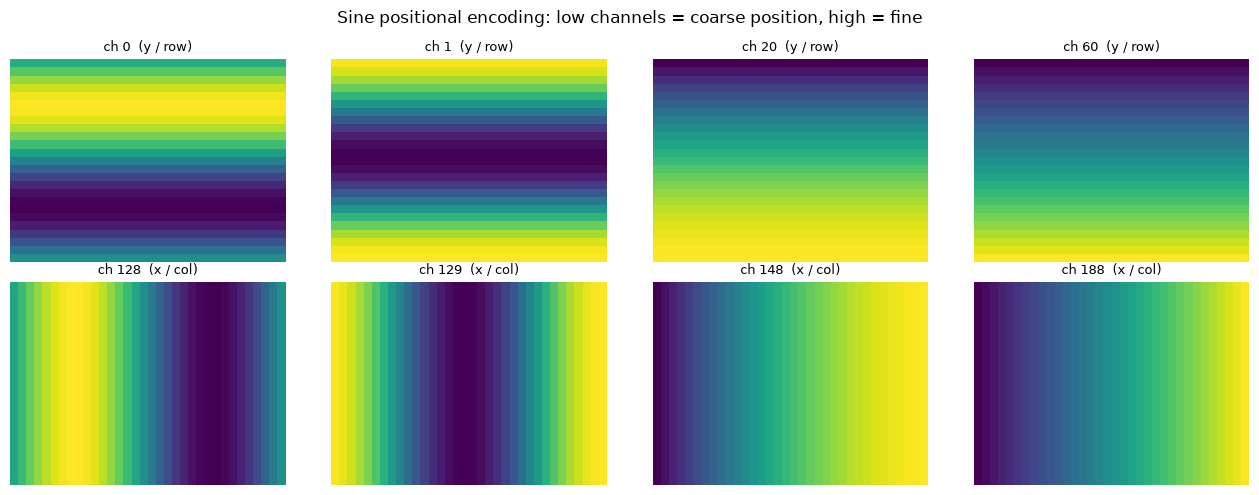

In [10]:
p = pos_embed[0].cpu()                       # shape: (256, H, W)

fig, axes = plt.subplots(2, 4, figsize=(13, 5))
for j, ch in enumerate([0, 1, 20, 60]):
    axes[0, j].imshow(p[ch]);       axes[0, j].set_title(f"ch {ch}  (y / row)", fontsize=9)
    axes[1, j].imshow(p[128 + ch]); axes[1, j].set_title(f"ch {128+ch}  (x / col)", fontsize=9)
for ax in axes.ravel(): ax.axis("off")
plt.suptitle("Sine positional encoding: low channels = coarse position, high = fine")
plt.tight_layout(); plt.show()

Top row varies only **vertically** (it encodes the row), bottom row only **horizontally** (the column). Low channels are slow, smooth gradients; higher channels oscillate faster. Together, the 256 numbers at a grid cell form a unique fingerprint of its (x, y) — the same trick as binary place-value, but continuous.

### A subtlety: positions are *added at every attention layer*, not once at the input

In the original transformer you add the positional encoding to the input embedding once. DETR instead re-adds it to the **query and key** (but *not* the value) inside every attention layer:

In [11]:
import inspect
from models.transformer import TransformerEncoderLayer
print(inspect.getsource(TransformerEncoderLayer.with_pos_embed))
print(inspect.getsource(TransformerEncoderLayer.forward_post))

    def with_pos_embed(self, tensor, pos: Optional[Tensor]):
        return tensor if pos is None else tensor + pos

    def forward_post(self,
                     src,
                     src_mask: Optional[Tensor] = None,
                     src_key_padding_mask: Optional[Tensor] = None,
                     pos: Optional[Tensor] = None):
        q = k = self.with_pos_embed(src, pos)
        src2 = self.self_attn(q, k, value=src, attn_mask=src_mask,
                              key_padding_mask=src_key_padding_mask)[0]
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src



Note `q = k = self.with_pos_embed(src, pos)` but `value=src`. Position influences *where to look* (the attention weights) but is not mixed into *what is retrieved* (the content).

The paper ablates this in **Table 3**: passing sine encodings at every attention layer scores **40.6 AP**; passing them once at the input drops to 39.2; removing spatial encodings entirely collapses to 32.8 (−7.8 AP). Position matters enormously.

## 6. The full journey, verified end to end

In [12]:
with torch.no_grad():
    feats, poss = model.backbone(single)
    s, m = feats[-1].decompose()
    pj = model.input_proj(s)
    sq = pj.flatten(2).permute(2, 0, 1)
    pe = poss[-1].flatten(2).permute(2, 0, 1)

rows = [
    ("PIL image",              f"(W={im.size[0]}, H={im.size[1]})"),
    ("after transform",        tuple(default_transform(im).shape)),
    ("batched (NestedTensor)", tuple(single.tensors.shape)),
    ("  + padding mask",       tuple(single.mask.shape)),
    ("ResNet-50 layer4",       tuple(s.shape)),
    ("input_proj (1x1 conv)",  tuple(pj.shape)),
    ("flattened sequence",     tuple(sq.shape)),
    ("positional encoding",    tuple(pe.shape)),
]
print(f"{'stage':<24} shape")
print("-" * 52)
for k, v in rows:
    print(f"{k:<24} {v}")
print()
print("The last two are what the transformer encoder actually receives.")

stage                    shape
----------------------------------------------------
PIL image                (W=640, H=480)
after transform          (3, 800, 1066)
batched (NestedTensor)   (1, 3, 800, 1066)
  + padding mask         (1, 800, 1066)
ResNet-50 layer4         (1, 2048, 25, 34)
input_proj (1x1 conv)    (1, 256, 25, 34)
flattened sequence       (850, 1, 256)
positional encoding      (850, 1, 256)

The last two are what the transformer encoder actually receives.


## What's next

`03` picks up exactly here: it feeds this `(850, 1, 256)` sequence into the encoder, then introduces the **object queries** that turn encoder memory into 100 predictions.

### Try it yourself

- Run §2 with `load_image("horses")`. What grid size do you get? Does `H*W` match the token count?
- The paper's **DETR-DC5** variant removes the stride from ResNet's last stage, doubling the feature resolution. Rebuild with `build_detr(dilation=True)` and check the new grid — how many tokens now, and how does that hit the O(L²) attention cost?
- Plot positional-encoding channel `127` and `255`. Why do they look almost constant? (Hint: `dim_t = temperature ** (2*(i//2)/128)` — what happens as `i → 128`?)